# Soil Texture and Structure — Interactive Notebook

**MOOC "The Hydrology of Soil" — Chapter 1**
*Companion to the slides "Texture and Structure of soils" (R. Rigon)*

---

This notebook has **two interactive exercises**:

1. **The texture triangle.** You choose the percentages of sand, silt and clay;
   the notebook returns the **USDA textural class name** (sandy loam, silty clay, …)
   and plots the point inside the texture triangle.

2. **The granulometric curve.** You shape a **grain-size distribution curve**
   (the "percentage finer" curve from the slides) by moving a few parameters,
   and the notebook draws it and tells you how the soil is classified —
   which size fraction dominates, and whether it is **well-graded** or
   **poorly-graded (uniform)**.

Both exercises work in two ways:

* with **interactive sliders**, if the package `ipywidgets` is installed;
* with **plain function calls** otherwise — every function can simply be called
  with numbers, so the notebook is fully usable in any environment.

Run the cells in order (Shift+Enter).


## 0 — Setup

In [ ]:
try:
    from soil_course import *
    print("soil_course already available")
except ModuleNotFoundError:
    !pip install git+https://github.com/panzerotto/soil_course.git
    from soil_course import *

print("Setup complete")

  Cloning https://github.com/panzerotto/soil_course.git to /tmp/pip-req-build-11ot09xz
  Running command git clone --filter=blob:none --quiet https://github.com/panzerotto/soil_course.git /tmp/pip-req-build-11ot09xz
  Resolved https://github.com/panzerotto/soil_course.git to commit e4d246166c300a95384779080d95c6a43f82efdc
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for soil-course: filename=soil_course-0.1.0-py3-none-any.whl size=7329 sha256=e0c787bf7e570de4772b885848c218fdd1acf125b0a38b0cc7f6e24fc3d35b51
  Stored in directory: /tmp/pip-ephem-wheel-cache-aph64icd/wheels/d1/cc/3a/6e11e3051820dbb8642dabb07e7fbe97d50387e4b7f07545bd
Successfully built soil-course
Setup complete


**Note for teachers:** all long formulas, plotting code and slider code are now hidden in the `soil_course` package. Students only call the short functions shown in each code cell.


---
# Part 1 — The USDA texture triangle

A soil is described by three numbers — the **mass percentages of sand, silt
and clay** — which must sum to 100 %. The **USDA texture triangle** divides
that space into twelve named classes.

The size classes (from the slides) are:

| fraction | diameter |
|----------|----------|
| sand     | 0.05 – 2 mm |
| silt     | 0.002 – 0.05 mm |
| clay     | < 0.002 mm |

(Particles larger than 2 mm are *gravel* and are excluded before computing
the percentages.)

The cell below contains the function `usda_texture_class(sand, clay)`. Silt is
obtained as `silt = 100 - sand - clay`, so two numbers are enough.


In [ ]:
# Quick check: classify one soil sample
usda_texture_class(sand=40, clay=20)


'Loam'

In [ ]:
check_usda_texture_examples()


sand= 90%  clay=  5%  ->  Sand              (expected ~ Sand)
sand= 40%  clay= 40%  ->  Clay              (expected ~ Clay)
sand= 40%  clay= 20%  ->  Loam              (expected ~ Loam)
sand= 20%  clay= 10%  ->  Silt loam         (expected ~ Silt loam)
sand= 65%  clay= 10%  ->  Sandy loam        (expected ~ Sandy loam)


### 1.1 — Drawing the triangle

The next cell defines `plot_texture_triangle(sand, clay)`, which draws the
triangle, the twelve class regions (as light guide lines), and marks **your
point** with a red dot. The classification name is printed in the title.


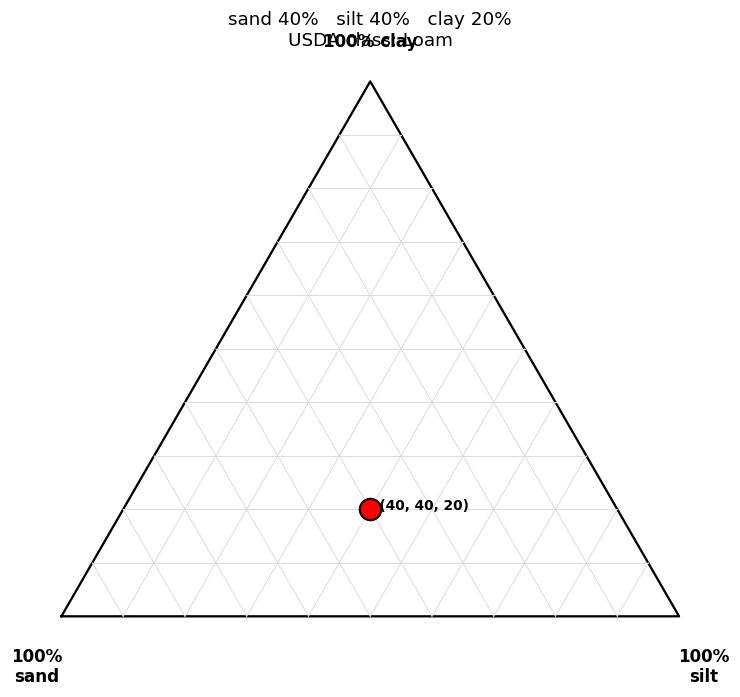

'Loam'

In [ ]:
plot_texture_triangle(sand=40, clay=20)


### 1.2 — Interactive version (sliders)

Move the **sand** and **clay** sliders. Silt is whatever is left over, so the
slider ranges are coupled: if `sand + clay` exceeds 100 the point is flagged as
invalid.

> If `ipywidgets` is **not** installed, this cell simply prints a message —
> use `plot_texture_triangle(sand=..., clay=...)` directly instead.


In [ ]:
interactive_texture_triangle()


interactive(children=(FloatSlider(value=40.0, continuous_update=False, description='sand %', step=1.0), FloatS…

**Try these:**

* `sand = 90, clay = 5`  → a *Sand*
* `sand = 40, clay = 40` → a *Clay*
* `sand = 40, clay = 20` → a *Loam* (the cyan dot on the slide's triangle)
* `sand = 10, clay = 10` → a *Silt loam*
* `sand = 55, clay = 30` → a *Sandy clay loam*

Notice how the **same clay percentage** can give very different class names
depending on the sand/silt balance — clay content alone does not name a soil.


---
# Part 2 — The granulometric (grain-size) curve

The second figure of the slides is the **grain-size distribution curve**:
the *x*-axis is grain diameter on a logarithmic scale, the *y*-axis is the
**percentage of the soil mass finer than that diameter**.

The curve is always **monotonically increasing** from 0 % to 100 %.
Its **position** tells you which fraction dominates (clay / silt / sand /
gravel) and its **steepness** tells you whether the soil is:

* **poorly-graded (uniform)** — a steep curve: most grains have nearly the
  same size;
* **well-graded** — a gentle curve spanning many decades: a broad mixture of
  sizes.

We model the curve with a smooth, adjustable shape so you can explore it.


### 2.1 — A parametric grain-size curve

A convenient and widely used model for the percentage-finer curve is the
**lognormal cumulative distribution**: grain *diameters* are lognormally
distributed, which on the usual log-diameter axis gives the familiar
S-shaped curve.

It has just two parameters:

* **`d50`** — the *median* grain diameter (mm): the diameter at which the
  curve crosses 50 %. This sets the **horizontal position** of the curve.
* **`sigma`** — the *spread* (standard deviation of `ln d`): how many decades
  of diameter the curve spans. This sets the **steepness**.
  Small `sigma` → steep → uniform;  large `sigma` → gentle → well-graded.

The percentage finer at diameter *d* is

$$N(d) \;=\; 100 \times \tfrac{1}{2}\Big[\,1 + \operatorname{erf}\!\Big(\frac{\ln d - \ln d_{50}}{\sigma\sqrt{2}}\Big)\Big].$$


In [ ]:
print_grain_curve_classification(d50=0.3, sigma=0.5)


fractions   : {'clay': 0.0, 'silt': 0.01694980864466178, 'sand': 99.97564537171708, 'gravel': 0.007404819638253457}
dominant    : sand
D10         : 0.15806505548881092
D30         : 0.23080708189927765
D60         : 0.3405139269508674
Cu          : 2.1542644318052426
Cc          : 0.9897545642349849
grading     : poorly-graded (uniform)
name        : poorly-graded (uniform) sand


{'fractions': {'clay': 0.0,
  'silt': 0.01694980864466178,
  'sand': 99.97564537171708,
  'gravel': 0.007404819638253457},
 'dominant': 'sand',
 'D10': 0.15806505548881092,
 'D30': 0.23080708189927765,
 'D60': 0.3405139269508674,
 'Cu': 2.1542644318052426,
 'Cc': 0.9897545642349849,
 'grading': 'poorly-graded (uniform)',
 'name': 'poorly-graded (uniform) sand'}

### 2.2 — Classifying the curve

Two standard descriptors classify a grain-size curve.

**(a) Which fraction dominates.** We read off the percentage of mass in each
USDA class directly from the curve:

* clay  $= N(0.002)$
* silt  $= N(0.05) - N(0.002)$
* sand  $= N(2) - N(0.05)$
* gravel $= 100 - N(2)$

The class with the largest percentage is the *dominant* fraction.

**(b) Well-graded or poorly-graded.** Geotechnics uses two numbers built from
the diameters at 10 %, 30 % and 60 % finer:

* **Uniformity coefficient**  $C_u = D_{60}/D_{10}$
* **Coefficient of curvature** $C_c = D_{30}^{\,2}\,/\,(D_{10}\,D_{60})$

A soil is **well-graded** if it spans a broad range of sizes
($C_u$ large, and $C_c$ between 1 and 3); otherwise it is **poorly-graded
(uniform)**. A steep lognormal curve has $C_u$ close to 1.


In [ ]:
# example
info = classify_grain_curve(d50=0.3, sigma=0.5)
for k, v in info.items():
    print(f"{k:12s}: {v}")


fractions   : {'clay': 0.0, 'silt': 0.01694980864466178, 'sand': 99.97564537171708, 'gravel': 0.007404819638253457}
dominant    : sand
D10         : 0.15806505548881092
D30         : 0.23080708189927765
D60         : 0.3405139269508674
Cu          : 2.1542644318052426
Cc          : 0.9897545642349849
grading     : poorly-graded (uniform)
name        : poorly-graded (uniform) sand


### 2.3 — Drawing the curve

The long plotting code is now hidden in `plot_grain_curve(d50, sigma)`.


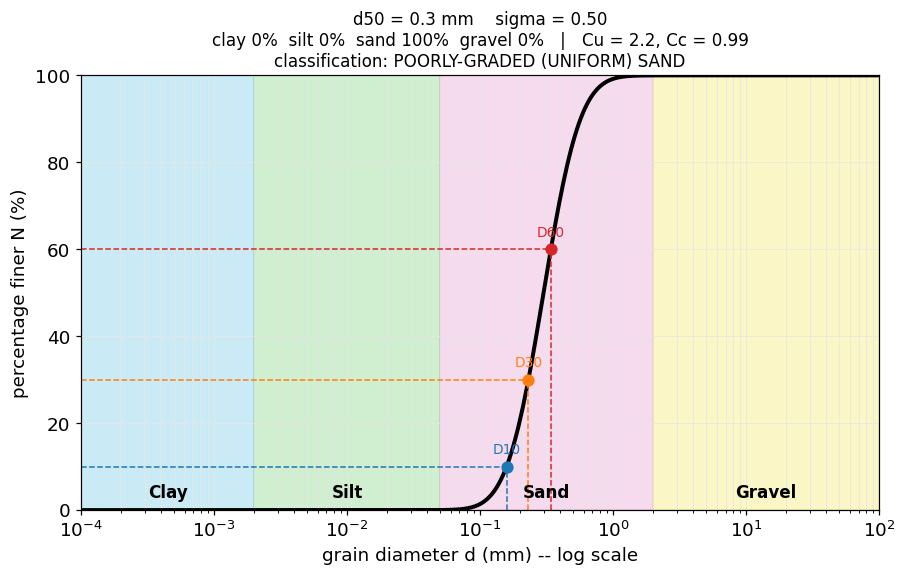

{'fractions': {'clay': 0.0,
  'silt': 0.01694980864466178,
  'sand': 99.97564537171708,
  'gravel': 0.007404819638253457},
 'dominant': 'sand',
 'D10': 0.15806505548881092,
 'D30': 0.23080708189927765,
 'D60': 0.3405139269508674,
 'Cu': 2.1542644318052426,
 'Cc': 0.9897545642349849,
 'grading': 'poorly-graded (uniform)',
 'name': 'poorly-graded (uniform) sand'}

In [ ]:

plot_grain_curve(d50=0.3, sigma=0.5)


### 2.4 — Interactive version (sliders)

Move the two sliders:

* **`d50`** slides the curve **left** (finer soil) or **right** (coarser soil);
* **`sigma`** makes it **steep** (uniform) or **gentle** (well-graded).

> Without `ipywidgets`, call `plot_grain_curve(d50=..., sigma=...)` directly.


In [ ]:
interactive_grain_curve()


interactive(children=(FloatSlider(value=-0.5228787452803376, continuous_update=False, description='log10 d50',…

**Try these:**

| `d50` (mm) | `sigma` | what you should see |
|-----------|---------|---------------------|
| 0.3  | 0.4 | a **poorly-graded sand** — steep curve sitting in the pink band |
| 0.3  | 1.8 | a **well-graded** soil — gentle curve spanning silt+sand+gravel |
| 0.005 | 0.5 | a **poorly-graded silt** — steep curve in the green band |
| 0.001 | 0.6 | a **clay** — curve in the blue ("Brownian behavior") band |
| 8.0  | 0.5 | a **poorly-graded gravel** — steep curve in the yellow band |

Compare a **steep** curve with a **gentle** one at the same `d50`: same median
size, completely different engineering behaviour. This is exactly the
"poorly graded vs well graded" distinction sketched on slide 8 of the lecture.


---
# Part 3 — Linking the two: from grain sizes to a triangle point

The grain-size curve gives the **sand / silt / clay percentages** (Part 2),
and those three numbers place the soil on the **texture triangle** (Part 1).
The cell below closes the loop: pick a curve, get its triangle class.

Note the **caveat from the slides**: texture (and therefore the triangle) is
*not* the whole story. Two soils with identical texture can behave very
differently because of **structure** — how the grains pack into *aggregates*
with their own large inter-aggregate pores. Clay especially has a *bimodal*
pore structure. The triangle classifies the **grains**, not the **pores**.


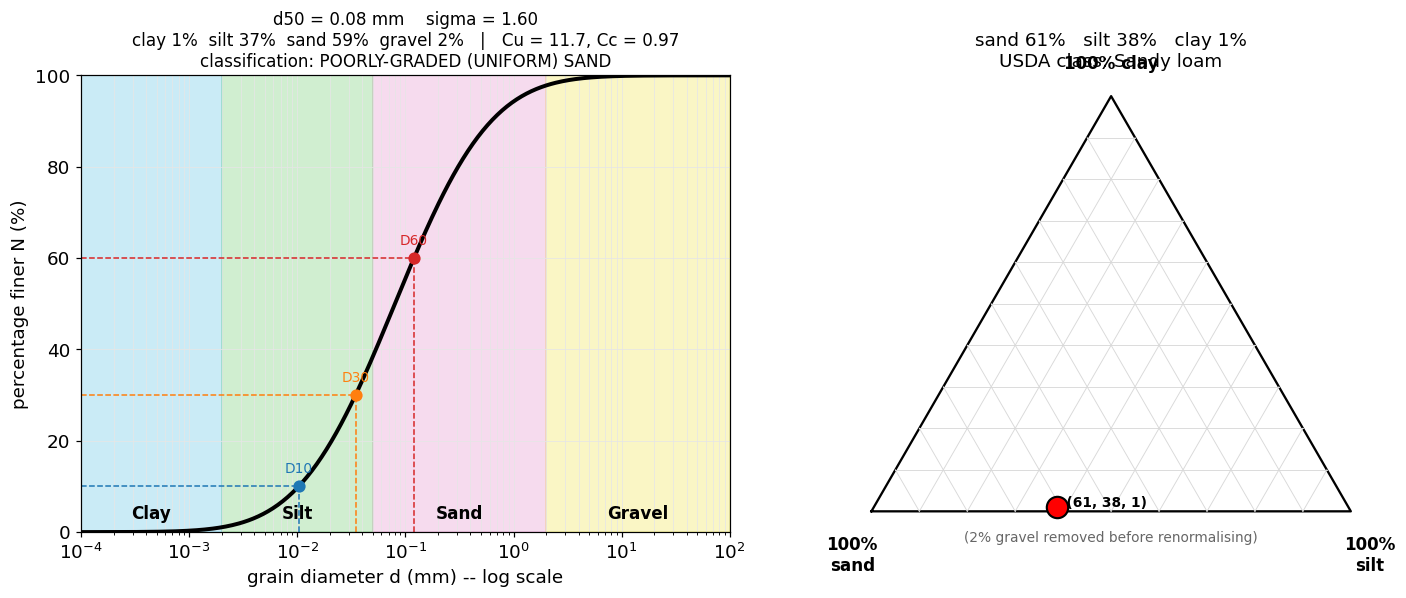

'Sandy loam'

In [ ]:
curve_to_triangle(d50=0.08, sigma=1.6)


In [ ]:
interactive_curve_to_triangle()


interactive(children=(FloatSlider(value=-1.0969100130080565, continuous_update=False, description='log10 d50',…

---
# Part 4 — Structure: how the grains are arranged

Parts 1–3 described the **grains**: their sizes and proportions. But two soils
with *identical texture* can behave completely differently in the field,
because what governs water storage and flow is the **pore space** — and the
pore space depends on **structure**, the way grains are packed and bound into
**aggregates**.

The slides make this point repeatedly:

* *"Texture alone does not explain soil porosity."*
* *"Smaller grains don't always mean smaller pores."*
* *"Clay platelets create disk-shaped aggregates with large pores."*
* *"The relationship between grain size and pore size is not direct."*

This part makes those statements quantitative. Students can:

1. see how **packing** alone changes porosity, with texture held fixed;
2. build a **bimodal pore structure** — small intra-aggregate pores plus large
   inter-aggregate pores — the structure the slides draw for clay;
3. compare a structured soil with a structureless one of the *same texture*.


### 4.1 — Packing: same grains, different porosity

Take a single grain size and just pack it differently. For identical spheres,
geometry alone gives a range of porosities:

| packing | porosity *n* | description |
|---------|-------------|-------------|
| dense (rhombohedral) | ≈ 0.26 | tightly shaken down |
| random close | ≈ 0.36 | typical poured sand |
| simple cubic | ≈ 0.48 | loose, open |
| card-house clay | up to ≈ 0.70+ | platelets propped open |

The grains never changed — only their **arrangement**. Porosity is a property
of *structure*, not of *texture*.


In [ ]:
print_packing_table()


packing                   porosity n   bulk density
---------------------------------------------------
dense (rhombohedral)            0.26        1.96 g/cm3
random close                    0.36        1.70 g/cm3
loose (cubic)                   0.48        1.38 g/cm3
card-house clay                 0.70        0.80 g/cm3

Same grains throughout - only the packing differs.


Notice the **bulk density** column: the soil scientist's most routine
field measurement is, in effect, a measurement of *structure*. A dense packing
and a loose packing of the very same sand differ in bulk density by more than
50%.


### 4.2 — Aggregates and the bimodal (dual-porosity) pore structure

Slide 12 draws clay's two-population pore space: grains clump into
**aggregates**, and the soil then has *two* distinct families of pores.
The literature has precise names for them:

* **textural porosity** — the small **intra-aggregate** pores, *inside* each
  aggregate. These are set by the packing of the primary grains (the "texture"
  of Parts 1–3).
* **structural porosity** — the large **inter-aggregate** pores (also called
  *interpedal* pores), *between* the aggregates, together with cracks and
  biopores. These are created by *structure* — aggregation, roots, fauna,
  shrink–swell.

The total pore-size distribution is then no longer a single hump: it is the
**weighted sum of two pore populations**, and it has **two peaks**. In soil
physics this is called a **bimodal** (or **dual-porosity**) pore-size
distribution. Modelling aggregated soils as two superimposed pore systems is
the *composite-porosity* approach of Durner (1994); the same two-domain idea
underlies the dual-porosity / dual-permeability flow models of
Gerke & van Genuchten (1993).

The function below builds exactly that bimodal distribution. Its key control,
which we now name the **structural fraction** `f_struct`, is the share of
total pore volume carried by the large *structural* (inter-aggregate) pores.

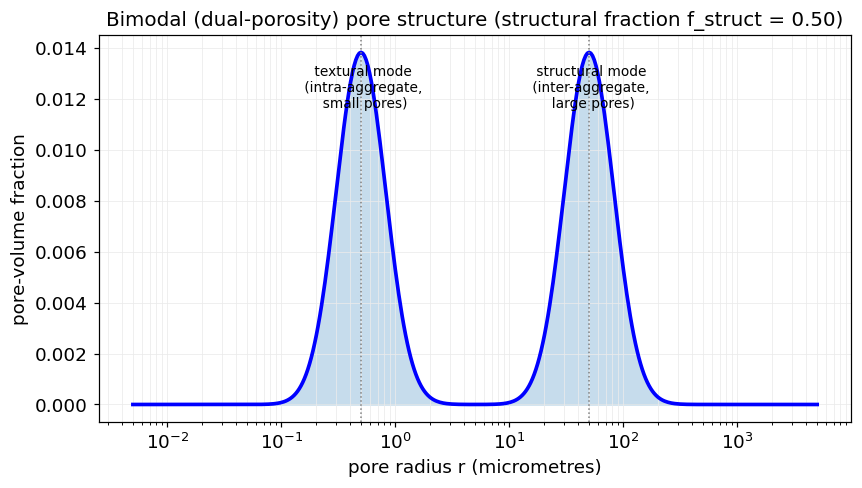

In [ ]:
plot_bimodal_pores(f_struct=0.5)


At `f_struct = 0` the distribution is a single textural hump — a
**structureless** soil (the USDA *single-grain* or *massive* condition). At
`f_struct = 1` it is a single structural hump. In between — and this is the
point — it is genuinely **two-peaked**: the **bimodal / dual-porosity**
signature of an aggregated soil, and exactly the picture the slide draws for
clay.

> **A note on naming — what this curve is, and what it is not.**
>
> The two-peaked curve above is a property of the **pore space**. In the
> unsaturated-flow literature it is called a **bimodal** or **dual-porosity
> pore-size distribution**, and its two parts are the **textural** (intra-
> aggregate, matrix) porosity and the **structural** (inter-aggregate,
> interpedal) porosity. Durner (1994) introduced the bimodal retention curve
> for exactly such soils; Gerke & van Genuchten (1993) built the matching
> dual-porosity flow model.
>
> This is **not** the same as the **USDA soil-structure classes**, which name
> the *shape of the visible aggregates (peds)* a soil scientist logs in a pit:
> *granular* (and the very porous, organic-rich variant *crumb*), *(sub)angular
> blocky*, *prismatic*, *columnar*, *platy*, plus the two structureless
> conditions *single-grain* and *massive*.
>
> So the soil this notebook builds — rounded, porous aggregates that drain
> freely — would be logged in the field as **granular structure** (or *crumb*
> if highly porous and organic-rich). If instead the aggregates were dense,
> sharp-edged clay clods formed by shrink–swell, the field name would be
> **(subangular) blocky** structure. Both of those ped types *produce* the
> bimodal pore-size distribution modelled here; the model captures the
> *pore consequence* of structure, not the ped *shape* itself.
>
> *References:* Durner, W. (1994), *Water Resour. Res.* 30(2), 211–223;
> Gerke, H.H. & M.Th. van Genuchten (1993), *Water Resour. Res.* 29(2),
> 305–319; USDA *Soil Survey Manual* (structure classes).

### 4.3 — Interactive: build a structure

Move the sliders:

* **structural fraction** `f_struct` — slide from a structureless soil (0,
  textural pores only) to a fully structural one (1) and watch the second peak
  grow. This is the single knob that turns "structure" on and off.
* **textural / structural radii** — the median radii of the two pore
  populations.
* **spread** — how wide each population is.

A soil with a clear two-peak curve and rounded, porous aggregates is, in field
terms, a **granular** (or **crumb**) structure; the same bimodal curve built
from dense clay clods would be logged as **blocky**.

> Without `ipywidgets`, call `plot_bimodal_pores(...)` directly.

In [ ]:
interactive_bimodal_pores()


interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='f_struct', max=1.0, step=0.…

### 4.4 — Why structure matters: drainage

A quick, deliberately simple consequence. Large pores drain fast and hold
little water against gravity; small pores hold water tightly. A useful rough
rule: pores **larger than about 25 µm** drain freely (they make up the
*air capacity* of a soil), while smaller pores retain water.

The function below splits the pore volume of a structure at that cutoff and
reports the freely-draining fraction as the **structural fraction** `f_struct`
is increased — a first proxy for how a soil behaves in the field.

In [ ]:
print_drainage_table()


freely-draining pore fraction (pores > 25 um):

    f_struct    draining   retentive
        0.00        0.00        1.00
        0.25        0.23        0.77
        0.50        0.46        0.54
        0.75        0.69        0.31
        1.00        0.92        0.08

Same texture every row -- only the structural fraction changes.
More structural porosity -> more large inter-aggregate pores -> faster drainage.


Every row of that table is the **same texture**. The only thing that
changes is the **structure** — and the freely-draining fraction swings widely
across it. This is the quantitative version of the slide-12 message, and it is
the bridge to Chapter 2, where these pores become the *retention curve*.


---
## Exercises for students

1. **Packing, not grains.** In Part 4.1, which packing gives the highest bulk density? Explain why a single sieved sand can be placed in the field at two different bulk densities, and what that does to its porosity.

2. **Build a clay.** In Part 4.3, set a small `r_textural`, a large `r_structural`, and slide the structural fraction `f_struct` from 0 to 1. At which value does the distribution first look genuinely *two-peaked*? Name the pore-system class (bimodal / dual-porosity) and say which USDA ped type — *granular* or *blocky* — you would log in the field if the aggregates were (a) rounded and porous, (b) dense clay clods.

3. **Structure controls drainage.** Using Part 4.4, take a single texture and report the freely-draining fraction for `f_struct = 0` and for `f_struct = 0.8`. Two field samples of this *same soil* are given to you — one a well-developed granular structure, one compacted and structureless (*massive*) — which drains faster after rain, and by roughly how much?

---

*Notebook prepared as a companion to the MOOC "The Hydrology of Soil",
Chapter 1 — Texture and Structure. Licensed CC BY-SA, consistent with the
lecture slides.*


---

## References

The methods and classifications used in this notebook draw on the following
sources, organised by the Part that uses them.

**Part 1 — the texture triangle**

* Soil Survey Staff (2017). *Soil Survey Manual* (USDA Handbook No. 18),
  U.S. Department of Agriculture. — definition of the USDA particle-size
  classes (sand / silt / clay) and the textural-class triangle.

**Part 2 — the grain-size curve and its grading**

* ASTM D2487, *Standard Practice for Classification of Soils for Engineering
  Purposes (Unified Soil Classification System)*, ASTM International. —
  the coefficient of uniformity $C_u = D_{60}/D_{10}$, the coefficient of
  curvature $C_c = D_{30}^{2}/(D_{10}D_{60})$, and the well-graded vs
  poorly-graded criteria. The USCS itself was developed by A. Casagrande
  (1948), "Classification and identification of soils," *Transactions of the
  ASCE*, 113: 901–930.
* ASTM D6913, *Standard Test Methods for Particle-Size Distribution
  (Gradation) of Soils Using Sieve Analysis*. — the percentage-finer
  (granulometric) curve and the characteristic diameters $D_{10}, D_{30},
  D_{60}$.
* The representation of the grain-size curve as a **lognormal** distribution
  of diameter is a long-standing and widely used model; see e.g.
  Fredlund, D.G., Fredlund, M.D. & Wilson, G.W. (2000), "An equation to
  represent grain-size distribution," *Canadian Geotechnical Journal*, 37(4):
  817–827.

**Part 4 — structure and the bimodal pore space**

* Brewer, R. (1964). *Fabric and Mineral Analysis of Soils.* Wiley, New York.
  — the distinction between **textural** (intra-aggregate) and **structural**
  (inter-aggregate) porosity.
* Durner, W. (1994). "Hydraulic conductivity estimation for soils with
  heterogeneous pore structure," *Water Resources Research*, 30(2): 211–223.
  — the **bimodal / composite-porosity** description of aggregated soils.
* Gerke, H.H. & van Genuchten, M.Th. (1993). "A dual-porosity model for
  simulating the preferential movement of water and solutes in structured
  porous media," *Water Resources Research*, 29(2): 305–319. — the matching
  **dual-porosity** flow model.
* Soil Survey Staff (2017). *Soil Survey Manual* (USDA Handbook No. 18). —
  the field **soil-structure (ped) classes**: granular, crumb, (sub)angular
  blocky, prismatic, columnar, platy, and the structureless conditions
  single-grain and massive.
* Fatichi, S., Or, D., Walko, R., et al. (2020). "Soil structure is an
  important omission in Earth System Models," *Nature Communications*, 11:
  522. — why structure, not texture alone, governs the hydraulic behaviour of
  real soils.

*These references support the companion bibliography of the MOOC "The
Hydrology of Soil".*